In [ ]:
import os
import torch
# print(torch.__version__)
print(os.name)
!python --version

posix
Python 3.11.13


In [ ]:
import xgboost, lightgbm
xgboost.__version__,lightgbm.__version__
# ('3.0.2', '4.6.0')

('3.0.2', '4.6.0')

In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import joblib
import gc

from xgboost import XGBClassifier as xgb

from sklearn import metrics
import random
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm

from scipy.stats import kurtosis, skew
# from scipy.stats import pearsonr
import seaborn as sns
from copy import deepcopy
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score



In [ ]:

def create_dir(path):
    if os.path.isdir(path)==False:
        os.makedirs(path)

def zeroonescale(img):
    ret=img.copy()
    ret=(ret-ret.min())/(ret.max()-ret.min())
    return ret
def zeroonescaleCH(img):
    ret=img.copy()
    for ch in range(img.shape[-1]):
        ret[...,ch]=zeroonescale(ret[...,ch])
    return ret
def robustCH(img, q05, q50, q95, channels=np.arange(12)):
    ret=img[...,channels].copy()
    for i, ch in enumerate(channels):
        ret[...,i]= (img[...,ch]-q50[ch])/(q95[ch]-q05[ch])
    return ret

def find_opt_thresh(targets, preds):
    bestthresh=0.5
    bestscore=-np.inf
    for i in range(98):
        thresh=0.01+i/100
        score= f1_score(targets, (preds>thresh).astype(int))
        if score>bestscore:
            bestscore=score
            bestthresh=thresh
    return round(bestthresh,2), bestscore

def plotImp(mfi, columns , num = 50, fig_size = (10, 10)):
    feature_imp = pd.DataFrame({'Value':mfi,'Feature':columns})
    plt.figure(figsize=fig_size)
    sns.set(font_scale = 1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",
                                                        ascending=False)[0:num])
    plt.title('LightGBM Features (avg over folds)')
    plt.tight_layout()
    plt.savefig('lgbm_importances-01.png')
    plt.show()

def feature_engineering(image):
    ndvi = (image[..., 3] - image[..., 0]) / (image[..., 3] + image[..., 0] + 1e-10)
    ndwi = (image[..., 3] - image[..., 1]) / (image[..., 3] + image[..., 1] + 1e-10)
    nirbleu = (image[..., 3] - image[..., 2]) / (image[..., 3] + image[..., 2] + 1e-10)

    bleugreen = (image[..., 2] - image[..., 1]) / (image[..., 2] + image[..., 1] + 1e-10)
    bleured = (image[..., 2] - image[..., 0]) / (image[..., 2] + image[..., 0] + 1e-10)
    greenred = (image[..., 1] - image[..., 0]) / (image[..., 1] + image[..., 0] + 1e-10)


    image = np.concatenate(
        [
            image,# * 2 - 1, # scale band data from -1 to 1
            np.expand_dims(ndvi+0.5, axis=-1),
            np.expand_dims(ndwi+0.5, axis=-1),
            np.expand_dims(nirbleu+0.5, axis=-1),

            np.expand_dims(bleugreen+0.5, axis=-1),
            np.expand_dims(bleured+0.5, axis=-1),
            np.expand_dims(greenred+0.5, axis=-1),

        ],
        axis=-1,
    )
    return image

In [ ]:
name='Landslide_Class_S2S1_v44'

N_folds=5
THRESH=0.5

In [ ]:
# set the paths
TEST_PROBS_PATH='/gdrive/My Drive/Colab Notebooks/Landslide_class/testProbs/'
SUBMISSIONS_PATH='/gdrive/My Drive/Colab Notebooks/Landslide_class/submissions/'
OOF_PATH='/gdrive/My Drive/Colab Notebooks/Landslide_class/OOF/'
LOGS_PATH='/gdrive/My Drive/Colab Notebooks/Landslide_class/logs/'
weights_path='/gdrive/My Drive/Colab Notebooks/Landslide_class/weights/'

In [ ]:
# Define paths for the dataset (remember to unzip the dataset first!)
train_csv_path = 'Train.csv'  # Path to the training labels CSV file
test_csv_path = 'Test.csv'    # Path to the test image IDs CSV file
train_data_path = 'train_data/train_data'  # Folder where .npy train files are located
test_data_path = 'test_data/test_data'    # Folder where .npy test files are located

# Load Train.csv and inspect the data
train_df = pd.read_csv(train_csv_path)
print("Train.csv:")
print(train_df.head())

Train.csv:
          ID  label
0  ID_HUD1ST      1
1  ID_KGE2HY      1
2  ID_VHV9BL      1
3  ID_ZT0VEJ      0
4  ID_5NFXVY      0


In [ ]:
train_df.label.value_counts()

,count
label,
0,5892
1,1255


In [ ]:
# Load all training data to ram
folder_path=train_data_path+'/'
X = np.array([np.load(folder_path+image_id+'.npy') for image_id in train_df['ID']])
y = train_df['label'].values

# Load all test data to ram
test_df = pd.read_csv(test_csv_path)
test_ids = test_df['ID'].values
X_test = np.array([np.load(test_data_path+'/'+image_id+'.npy') for image_id in test_ids])

In [ ]:

X[0].shape
def get_feats(ar):
    ar=feature_engineering(ar)
    feats=[]
    for ch in range(ar.shape[-1]):
        feats.extend([np.mean(ar[...,ch]),np.median(ar[...,ch]),np.min(ar[...,ch]),np.max(ar[...,ch]), np.std(ar[...,ch]), skew(ar[...,ch].flatten()), kurtosis(ar[...,ch].flatten())])
    return np.array(feats)
# get_feats(X[0])

In [ ]:
num_channels=feature_engineering(X[0]).shape[-1]
colnames=[['meanCH'+str(ch),'medianCH'+str(ch),'minCH'+str(ch),'maxCH'+str(ch),'stdCH'+str(ch),'skewCH'+str(ch),'kurtosisCH'+str(ch)] for ch in range(num_channels)]
colnames=np.hstack(colnames)
colnames.shape

(126,)

In [ ]:
Xfeats=np.stack([get_feats(X[i]) for i in tqdm(range(len(X)))])
Xfeats.shape

100%|██████████| 7147/7147 [02:45<00:00, 43.30it/s]


(7147, 126)

In [ ]:
Xtestfeats=np.stack([get_feats(X_test[i]) for i in tqdm(range(len(X_test)))])
Xtestfeats.shape

100%|██████████| 5398/5398 [02:02<00:00, 44.13it/s]


(5398, 126)

In [ ]:

ENCODER='XGB'
basename=ENCODER+'_'+name



In [ ]:

OOF=np.zeros(len(y))

N_folds=5
sgkf = KFold(n_splits=N_folds, random_state=42, shuffle=True)
val_true=np.zeros(len(X))
testpreds=np.zeros(len(X_test))
mfis=[]
for fold, (train_index, test_index) in enumerate(sgkf.split(y, y)):
    params = {
    'objective': 'binary:logistic',
    'learning_rate': 0.02,
    'n_estimators': 4000,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': 1.5,
    'lambda': 1.2,
    'random_state': 42
}

    # Instantiate XGBClassifier with the parameters
    model = xgb(**params)
    model.fit(Xfeats[train_index], y[train_index])

    joblib.dump(model, weights_path+name+'_fold'+str(fold))
    model=joblib.load(weights_path+name+'_fold'+str(fold))

    mfis.append(model.feature_importances_)

    preds = model.predict_proba(Xfeats[test_index])[:,1]
    testpreds += model.predict_proba(Xtestfeats)[:,1]/N_folds

    OOF[test_index]=preds
    val_true[test_index]=y[test_index]

    F1 = f1_score(y[test_index], (preds>THRESH).astype(int))
    print(F1)


    gc.collect()


0.8571428571428571
0.8690476190476191
0.9005847953216374
0.8523908523908524
0.8741418764302059


In [ ]:
f1_score(y, (OOF>THRESH).astype(int)), find_opt_thresh(y, OOF)

(0.8708094848732625, (0.33, 0.8747514910536779))

In [ ]:
np.savez( OOF_PATH+name, OOF)
np.savez( TEST_PROBS_PATH+name, testpreds)

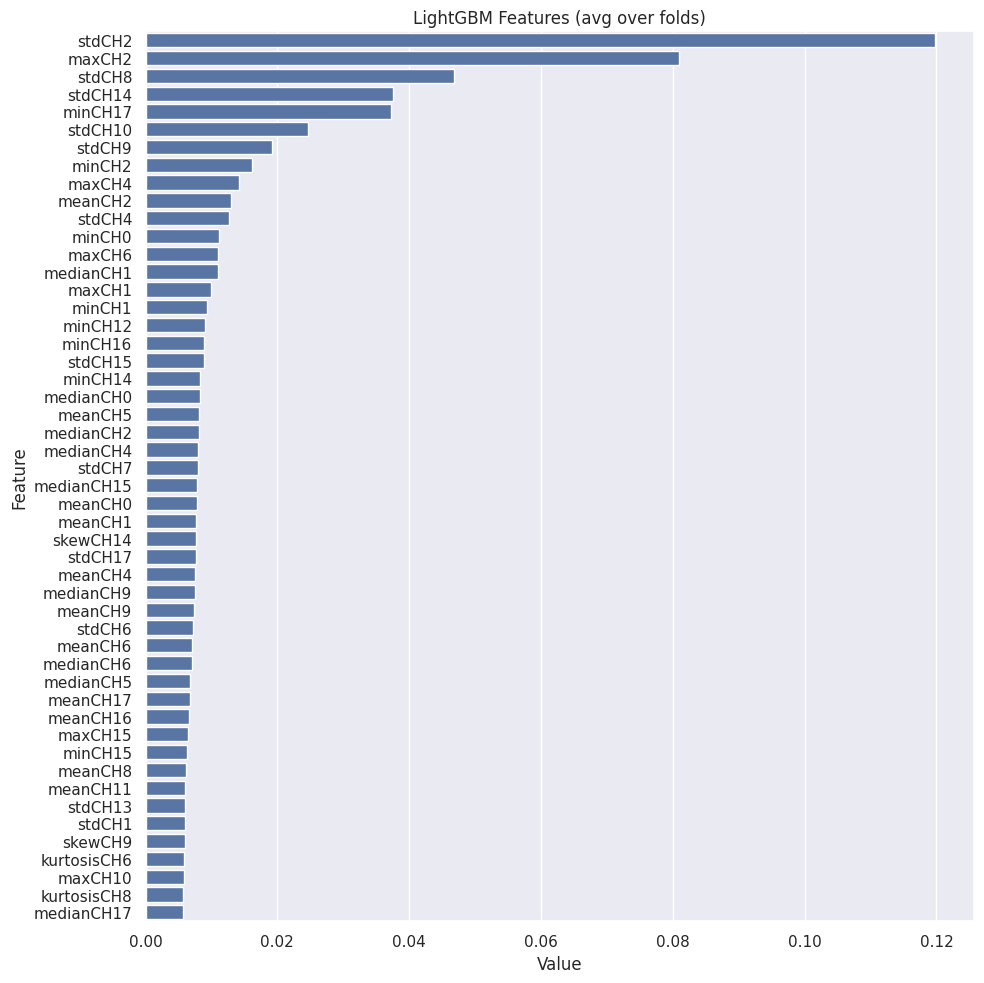

In [ ]:

# mfi= model.feature_importances_
mfi= np.stack(mfis).mean(0)
# columns=colnames
plotImp(model.feature_importances_, colnames)

In [30]:

bestthresh, bestscore=find_opt_thresh(y, OOF)
bestthresh, bestscore


(0.33, 0.8747514910536779)

In [ ]:

# 0.5 threshold
test_preds01 = (testpreds>0.5).astype(int)

unique, counts = np.unique(test_preds01, return_counts=True)
prediction_counts = dict(zip(unique, counts))
print("Prediction counts:", prediction_counts)

# Prepare submission file
submission_df = pd.DataFrame({
    'ID': test_ids,
    'label': test_preds01.flatten() })
submission_df.to_csv(SUBMISSIONS_PATH+name+'THRESH'+str(0.5)+'.csv', index=False)


THRESH=bestthresh
#bestThresh
test_preds01 = (testpreds>bestthresh).astype(int)
# Count the number of predictions for each class
unique, counts = np.unique(test_preds01, return_counts=True)
prediction_counts = dict(zip(unique, counts))
print("Prediction counts:", prediction_counts)

# Prepare submission file
submission_df = pd.DataFrame({
    'ID': test_ids,
    'label': test_preds01.flatten()  })
submission_df.to_csv(SUBMISSIONS_PATH+name+'THRESH'+str(bestthresh)+'.csv', index=False)

Prediction counts: {np.int64(0): np.int64(4775), np.int64(1): np.int64(623)}
Prediction counts: {np.int64(0): np.int64(4706), np.int64(1): np.int64(692)}
